# **Export libraries and view data**

In [169]:
!pip install kagglehub

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

from google.colab import drive


In [171]:
path = kagglehub.dataset_download("benjamin1717/taitanic")
print(f"the way to your path: {path}")

Using Colab cache for faster access to the 'taitanic' dataset.
the way to your path: /kaggle/input/taitanic


In [172]:
df = pd.read_csv(os.path.join(path, "train.csv"))
df.shape

# descripe # Survived -> y , PassengerId cus it doesn't matter, ticket  Name: transform to mr or lady to make searching easier
# shape # 891 columns , 12 Rows = feature
# feature engineering -> info() like if data type was float or int, it directly can use mean rather than use Encoding for string
# .columns # if it dtype was an object that mean you can not use it in model, which mean you need to use Encoding
# to filling missing data we will

(891, 12)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [174]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [175]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **Exploratory Data Analysis (EDA)**

<Axes: xlabel='Age', ylabel='Count'>

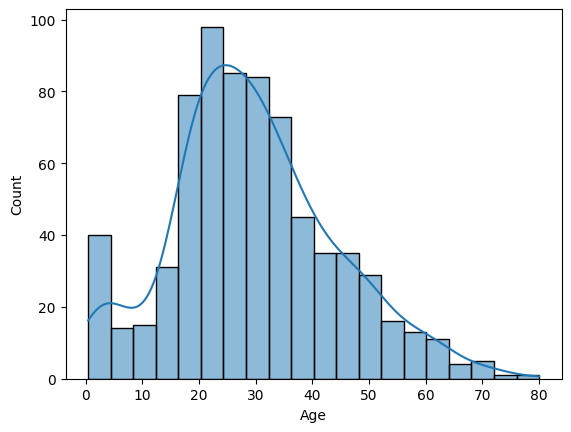

In [176]:
sns.histplot(df["Age"], kde=True) # to show what measure we'll use: Mode , Mean , Median

In [177]:
df["Embarked"].value_counts() # It shows how many times the data was repeated

,count
Embarked,
S,644
C,168
Q,77


<Axes: xlabel='Embarked', ylabel='count'>

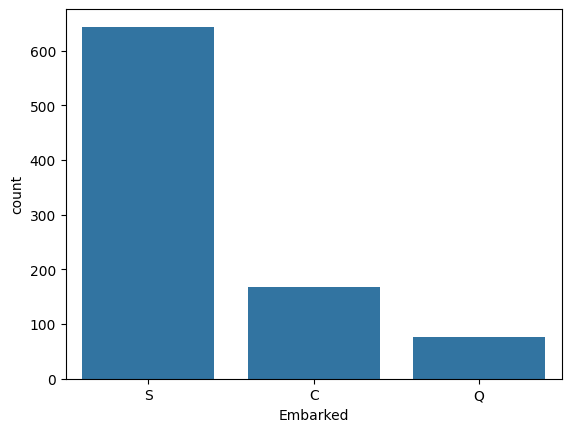

In [178]:
sns.countplot(data=df, x="Embarked")

<Axes: xlabel='Age'>

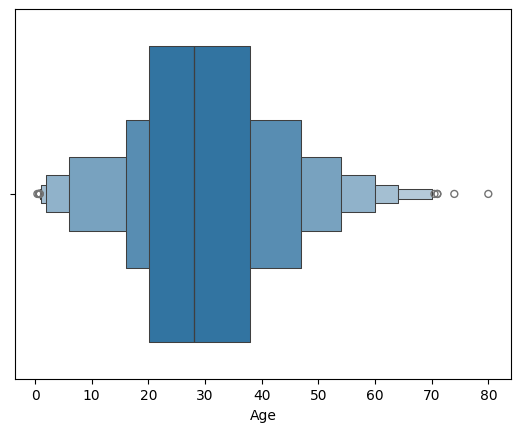

In [179]:
sns.boxenplot(x=df["Age"])

<Axes: xlabel='Fare'>

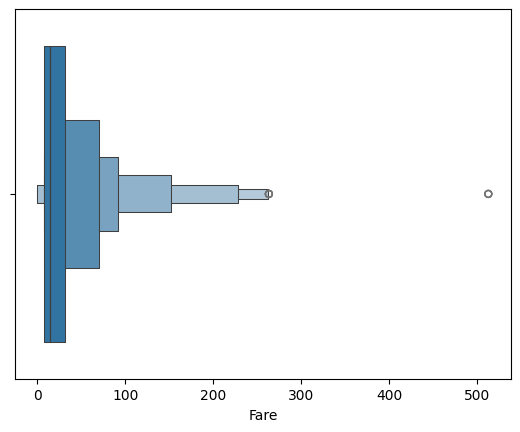

In [180]:
sns.boxenplot(x=df["Fare"])

In [181]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [182]:
df["Survived"].value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


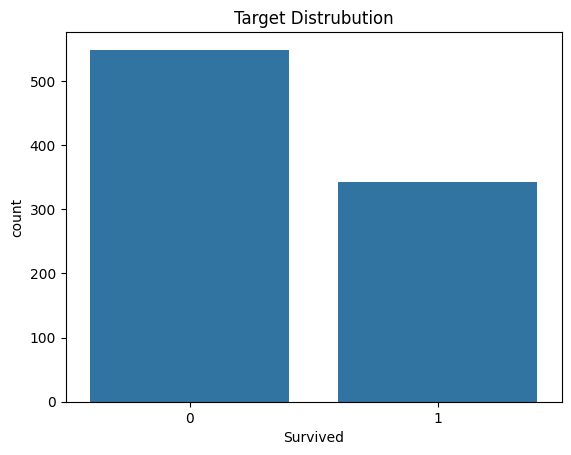

In [183]:
sns.countplot(data=df, x="Survived")
plt.title("Target Distrubution")
plt.show()

# **Data Cleaning**

In [184]:
df = df.drop(columns=["Ticket", "PassengerId", "Cabin"]) # Name , Sex , Embarked -> Encoding

df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [185]:
# Age Cleaning
df["Age"].median()
df["Age"] = df["Age"].fillna(df["Age"].median()) # Fill missing data with median
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2


In [186]:
df['Embarked'].mode()
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # Fill missing data with mode
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [187]:
df.duplicated().sum() #To check for duplicate rows

np.int64(0)

# **Preprocessing & Encoding & Feature Scaling**




In [188]:
df["Name"].head()

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"


In [189]:
df['Title'] = df['Name'].str.extract(r",\s*([^\.]+)\.")
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [190]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [191]:
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)
df

,Survived,Pclass,Name,Age,SibSp,Parch,Fare,Embarked,Title,Sex_male
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,S,Mr,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,C,Mrs,False
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,S,Miss,False
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,S,Mrs,False
4,0,3,"Allen, Mr. William Henry",35.0,0,0,8.0500,S,Mr,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",27.0,0,0,13.0000,S,Rev,True
887,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,30.0000,S,Miss,False
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,1,2,23.4500,S,Miss,False
889,1,1,"Behr, Mr. Karl Howell",26.0,0,0,30.0000,C,Mr,True


In [192]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [193]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df

,Survived,Pclass,Name,Age,SibSp,Parch,Fare,Title,Sex_male,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,Mr,True,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,Mrs,False,False,False
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,Miss,False,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,Mrs,False,False,True
4,0,3,"Allen, Mr. William Henry",35.0,0,0,8.0500,Mr,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",27.0,0,0,13.0000,Rev,True,False,True
887,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,30.0000,Miss,False,False,True
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,1,2,23.4500,Miss,False,False,True
889,1,1,"Behr, Mr. Karl Howell",26.0,0,0,30.0000,Mr,True,False,False


In [194]:
df = pd.get_dummies(df, columns=['Title'], drop_first=True)
df = df.drop(columns=['Name'])
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Col,...,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess
0,0,3,22.0,1,0,7.2500,True,False,True,False,...,False,False,False,False,True,False,False,False,False,False
1,1,1,38.0,1,0,71.2833,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
3,1,1,35.0,1,0,53.1000,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,0,3,35.0,0,0,8.0500,True,False,True,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
887,1,1,19.0,0,0,30.0000,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
888,0,3,28.0,1,2,23.4500,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
889,1,1,26.0,0,0,30.0000,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [195]:
df.info() # To check data values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Survived            891 non-null    int64  
 1   Pclass              891 non-null    int64  
 2   Age                 891 non-null    float64
 3   SibSp               891 non-null    int64  
 4   Parch               891 non-null    int64  
 5   Fare                891 non-null    float64
 6   Sex_male            891 non-null    bool   
 7   Embarked_Q          891 non-null    bool   
 8   Embarked_S          891 non-null    bool   
 9   Title_Col           891 non-null    bool   
 10  Title_Don           891 non-null    bool   
 11  Title_Dr            891 non-null    bool   
 12  Title_Jonkheer      891 non-null    bool   
 13  Title_Lady          891 non-null    bool   
 14  Title_Major         891 non-null    bool   
 15  Title_Master        891 non-null    bool   
 16  Title_Mi

In [196]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# cross validation



In [197]:
df.describe() # Feature Scaling

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [198]:
scaler = StandardScaler()

scaler.fit(X_train[["Age", "Fare"]])
#scaler.fit_transform
X_train[["Age", "Fare"]] = scaler.transform(X_train[["Age", "Fare"]])
X_test[["Age", "Fare"]] = scaler.transform(X_test[["Age", "Fare"]])

In [199]:
X_train[["Age", "Fare"]].describe()

,Age,Fare
count,7.120000e+02,7.120000e+02
mean,1.746418e-17,5.363999e-17
std,1.000703e+00,1.000703e+00
min,-2.214363e+00,-6.274674e-01
25%,-5.542135e-01,-4.748670e-01
50%,-9.263364e-02,-3.491435e-01
75%,4.458762e-01,-4.017244e-02
max,3.907725e+00,9.237724e+00


# **Model Training**

In [200]:
model = LogisticRegression()
model.fit(X_train, y_train)

# train multy models
# print report
# baseline model --

LogisticRegression()

In [201]:
print(model.intercept_)
print(model.coef_)

[3.5529116]
[[-0.85494745 -0.29419705 -0.469993   -0.34946819  0.22613818 -1.4864705
  -0.14391737 -0.43408465 -0.10877357  0.         -0.37568675  0.
   0.15548574 -0.10157117  1.60350593 -0.05614134  0.1187691   0.06101393
  -1.27379123  1.05102048  0.22123727 -0.91720382  0.          0.0994199 ]]


# **Model Testing**


*   Prediction
*   Evaluation



In [202]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 1 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1]


In [203]:
model.predict_proba(X_test)[:10]

array([[0.44093005, 0.55906995],
       [0.8158001 , 0.1841999 ],
       [0.89142204, 0.10857796],
       [0.17795079, 0.82204921],
       [0.32891416, 0.67108584],
       [0.07715054, 0.92284946],
       [0.33023652, 0.66976348],
       [0.94838433, 0.05161567],
       [0.27314854, 0.72685146],
       [0.15286541, 0.84713459]])

In [204]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8100558659217877


In [205]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[88, 17],
       [17, 57]])

In [206]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 81.01%


In [207]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2%}")

Precision: 77.03%


In [208]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2%}")

Recall: 77.03%


In [209]:
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.2%}")

F1 Score: 77.03%


In [210]:
print(classification_report(y_test, y_pred))
# Report presenting measurement results
# macro avg: To calculate the average of the metrics across categories without regard to the number of samples
# weighted avg : It assigns a weight to the category based on the number of samples

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       105
           1       0.77      0.77      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



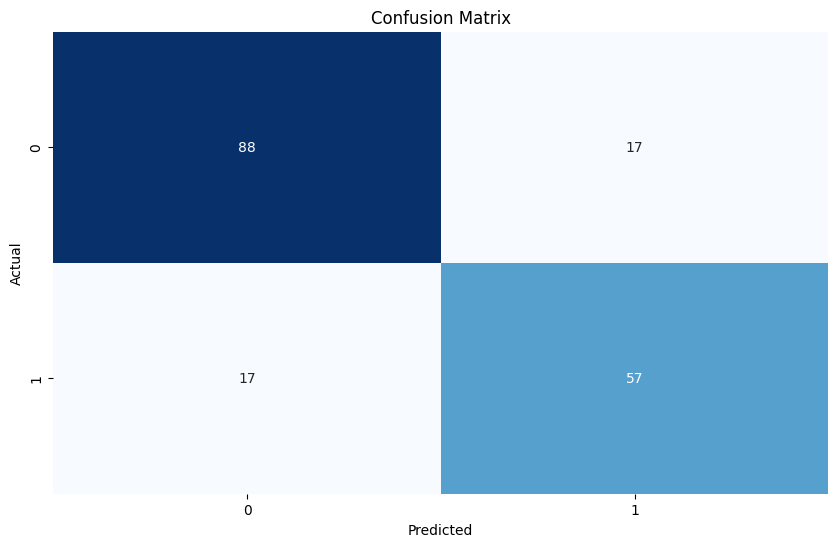

In [211]:
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()